In [1]:
# Imports 
import os, json, time, copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.optim import AdamW
from torch.optim.lr_scheduler import LambdaLR, CosineAnnealingLR, SequentialLR

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [2]:
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
print(f'PyTorch: {torch.__version__}')

Device : cuda
PyTorch: 2.10.0+cu128


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os
os.listdir("/content/drive/MyDrive/Projects_Data/Speech_to_Emotions/emotion_data/processed")

['y_labels.npy', 'features_combined.csv', 'X_features.npy', 'label_map.json']

In [18]:
# Load processed data
DATA_DIR   = Path('/content/drive/MyDrive/Projects_Data/Speech_to_Emotions/emotion_data/processed')
OUTPUT_DIR = Path('/content/drive/MyDrive/Projects_Data/Speech_to_Emotions/emotion_data/model_output')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

X_raw = np.load(DATA_DIR / 'X_features.npy')   # (9938, 378)
y_raw = np.load(DATA_DIR / 'y_labels.npy')      # (9938,)

with open(DATA_DIR / 'label_map.json') as f:
    lm           = json.load(f)
    label_to_int = lm['label_to_int']
    int_to_label = {int(k): v for k, v in lm['int_to_label'].items()}

NUM_CLASSES = len(label_to_int)
FEATURE_DIM = X_raw.shape[1]          # 378
SPECTRAL_DIM = 128                    # mel features (feat_0 to feat_127)
TEMPORAL_DIM = FEATURE_DIM - SPECTRAL_DIM  # 250 — MFCC + delta + prosodic

assert not np.isnan(X_raw).any()
assert not np.isinf(X_raw).any()

print(f'Samples      : {len(X_raw)}')
print(f'Feature dim  : {FEATURE_DIM}  (spectral={SPECTRAL_DIM}, temporal={TEMPORAL_DIM})')
print(f'Classes      : {NUM_CLASSES}  → {int_to_label}')
print('Data integrity: OK')

Samples      : 9938
Feature dim  : 378  (spectral=128, temporal=250)
Classes      : 6  → {0: 'angry', 1: 'disgust', 2: 'fear', 3: 'happy', 4: 'neutral', 5: 'sad'}
Data integrity: OK


In [19]:
# Train / Val / Test split (stratified)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_raw, y_raw, test_size=0.30, random_state=SEED, stratify=y_raw)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp)

print(f'Train: {len(y_train)}  Val: {len(y_val)}  Test: {len(y_test)}')

for name, y in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    counts = np.bincount(y, minlength=NUM_CLASSES)
    print(f'  {name}: ' + '  '.join(f'{int_to_label[i]}={c}' for i,c in enumerate(counts)))

Train: 6956  Val: 1491  Test: 1491
  Train: angry=1158  disgust=1159  fear=1158  happy=1158  neutral=1164  sad=1159
  Val: angry=248  disgust=248  fear=249  happy=248  neutral=250  sad=248
  Test: angry=249  disgust=248  fear=248  happy=249  neutral=249  sad=248


In [20]:
#  Normalize (fit on train only)
import joblib
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)
joblib.dump(scaler, OUTPUT_DIR / 'scaler.pkl')
print(f'Scaler fitted on {len(X_train)} samples. Saved.')

Scaler fitted on 6956 samples. Saved.


In [21]:
# Dataset with feature-group masking augmentation
#
# Feature groups in our 378-dim vector:
#   [0:128]   mel-spectrogram means  → spectral stream
#   [128:168] MFCC mean (40 coeff)
#   [168:208] MFCC std
#   [208:248] delta MFCC mean
#   [248:288] delta MFCC std
#   [288:378] prosodic (RMS, ZCR, centroid, bandwidth, rolloff)
#
# During training: add noise + randomly zero out entire feature groups.
# This forces the model to learn from multiple modalities, not rely on one.

class EmotionDataset(Dataset):
    def __init__(self, X, y, augment=False, noise_std=0.02, mask_prob=0.10):
        self.X         = torch.tensor(X, dtype=torch.float32)
        self.y         = torch.tensor(y, dtype=torch.long)
        self.augment   = augment
        self.noise_std = noise_std
        self.mask_prob = mask_prob
        n = X.shape[1]
        self.groups = [(0,128),(128,168),(168,208),(208,248),(248,288),(288,n)]

    def __len__(self): return len(self.y)

    def __getitem__(self, idx):
        x = self.X[idx].clone()
        if self.augment:
            x = x + torch.randn_like(x) * self.noise_std
            for s, e in self.groups:
                if torch.rand(1).item() < self.mask_prob:
                    x[s:e] = 0.0
        return x[:SPECTRAL_DIM], x[SPECTRAL_DIM:], self.y[idx]


def make_sampler(y):
    counts  = np.bincount(y, minlength=NUM_CLASSES)
    weights = 1.0 / (counts + 1e-8)
    return WeightedRandomSampler(
        torch.tensor(weights[y], dtype=torch.float32),
        num_samples=len(y), replacement=True)


BATCH_SIZE = 64

train_ds = EmotionDataset(X_train_sc, y_train, augment=True)
val_ds   = EmotionDataset(X_val_sc,   y_val,   augment=False)
test_ds  = EmotionDataset(X_test_sc,  y_test,  augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=make_sampler(y_train),
                          num_workers=2, pin_memory=(DEVICE.type=='cuda'))
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

xs, xt, lb = train_ds[0]
print(f'Spectral: {xs.shape}  Temporal: {xt.shape}  Label: {int_to_label[lb.item()]}')
print(f'Train batches: {len(train_loader)}  Val: {len(val_loader)}  Test: {len(test_loader)}')

Spectral: torch.Size([128])  Temporal: torch.Size([250])  Label: sad
Train batches: 109  Val: 24  Test: 24


#### We are building four different model architectures
    1. DSCANet          — dual-stream cross-attention (novel)
    2. BiLSTMAttention  — sequential temporal baseline
    3. CNNAttention     — spectral CNN baseline
    4. TransformerSER   — pure transformer baseline

In [22]:
# DS-CANet: Dual-Stream Cross-Attention Network
#
# Architecture overview:
#   Stream A: Linear projection → multi-head self-attention    (spectral)
#   Stream B: BiLSTM → Linear projection → self-attention      (temporal)
#   Cross-attention bridge: A queries B AND B queries A (bidirectional)
#   Gated fusion: learned sigmoid gate combines both enriched streams
#   Emotion-aware pooling: attention-weighted aggregation
#   Classifier: Linear → Dropout → output logits

# Emotion-Aware Pooling 
class EmotionAwarePooling(nn.Module):
    """Attention-weighted mean over the sequence dimension."""
    def __init__(self, d_model):
        super().__init__()
        self.score = nn.Linear(d_model, 1)
    def forward(self, x):                          # x: (B, T, d)
        w = F.softmax(self.score(x), dim=1)        # (B, T, 1)
        return (w * x).sum(dim=1)                  # (B, d)


# Gated Fusion 
class GatedFusion(nn.Module):
    """Learned sigmoid gate: output = z*a + (1-z)*b."""
    def __init__(self, d_model):
        super().__init__()
        self.gate = nn.Sequential(nn.Linear(d_model*2, d_model), nn.Sigmoid())
        self.norm = nn.LayerNorm(d_model)
    def forward(self, a, b):
        z = self.gate(torch.cat([a, b], dim=-1))
        return self.norm(z*a + (1-z)*b)


# ─────────────────────────────────────────────────────────────────────────────
# MODEL 1: DS-CANet (Dual-Stream Cross-Attention Network)
# novel architecture — academic contribution
# ─────────────────────────────────────────────────────────────────────────────
class DSCANet(nn.Module):
    def __init__(self, spectral_dim, temporal_dim, d_model=128,
                 num_heads=8, num_classes=6, dropout=0.5,
                 lstm_hidden=64, lstm_layers=2, temporal_steps=10):
        super().__init__()

        # Stream A — spectral (mel features)
        self.spec_proj = nn.Sequential(
            nn.Linear(spectral_dim, d_model), nn.LayerNorm(d_model), nn.GELU())
        self.spec_attn = nn.MultiheadAttention(d_model, num_heads, dropout=dropout, batch_first=True)
        self.spec_norm = nn.LayerNorm(d_model)

        # Stream B — temporal (MFCC + prosodic)
        assert temporal_dim % temporal_steps == 0
        step_dim = temporal_dim // temporal_steps
        self.step_proj  = nn.Linear(step_dim, lstm_hidden)
        self.bilstm     = nn.LSTM(lstm_hidden, lstm_hidden, lstm_layers,
                                  batch_first=True, bidirectional=True,
                                  dropout=dropout if lstm_layers>1 else 0)
        self.lstm_proj  = nn.Sequential(
            nn.Linear(2*lstm_hidden, d_model), nn.LayerNorm(d_model), nn.GELU())
        self.temp_attn  = nn.MultiheadAttention(d_model, num_heads, dropout=dropout, batch_first=True)
        self.temp_norm  = nn.LayerNorm(d_model)
        self.temporal_steps = temporal_steps

        # Cross-stream attention (the novel part)
        self.cross_a2b  = nn.MultiheadAttention(d_model, num_heads, dropout=dropout, batch_first=True)
        self.cross_b2a  = nn.MultiheadAttention(d_model, num_heads, dropout=dropout, batch_first=True)
        self.ca_norm_a  = nn.LayerNorm(d_model)
        self.ca_norm_b  = nn.LayerNorm(d_model)
        self.ffn_a = nn.Sequential(nn.Linear(d_model,d_model*2),nn.GELU(),nn.Dropout(dropout),nn.Linear(d_model*2,d_model))
        self.ffn_b = nn.Sequential(nn.Linear(d_model,d_model*2),nn.GELU(),nn.Dropout(dropout),nn.Linear(d_model*2,d_model))
        self.ffn_norm_a = nn.LayerNorm(d_model)
        self.ffn_norm_b = nn.LayerNorm(d_model)

        self.pool_a  = EmotionAwarePooling(d_model)
        self.pool_b  = EmotionAwarePooling(d_model)
        self.fusion  = GatedFusion(d_model)
        self.drop    = nn.Dropout(dropout)
        self.head    = nn.Sequential(
            nn.Linear(d_model, d_model//2), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(d_model//2, num_classes))

    def forward(self, x_spec, x_temp):
        # Stream A
        a = self.spec_proj(x_spec).unsqueeze(1)          # (B,1,d)
        ao, _ = self.spec_attn(a, a, a)
        a = self.spec_norm(a + self.drop(ao))            # (B,1,d)

        # Stream B
        B = x_temp.size(0)
        b = x_temp.view(B, self.temporal_steps, -1)
        b = self.step_proj(b)
        b, _ = self.bilstm(b)
        b = self.lstm_proj(b)                            # (B,T,d)
        bo, _ = self.temp_attn(b, b, b)
        b = self.temp_norm(b + self.drop(bo))

        # Cross-attention: A queries B
        ao2, _ = self.cross_a2b(query=a, key=b, value=b)
        a = self.ca_norm_a(a + self.drop(ao2))
        a = self.ffn_norm_a(a + self.ffn_a(a))

        # Cross-attention: B queries A
        bo2, _ = self.cross_b2a(query=b, key=a, value=a)
        b = self.ca_norm_b(b + self.drop(bo2))
        b = self.ffn_norm_b(b + self.ffn_b(b))

        a = self.pool_a(a)    # (B,d)
        b = self.pool_b(b)    # (B,d)
        return self.head(self.fusion(a, b))

In [23]:
# ─────────────────────────────────────────────────────────────────────────────
# MODEL 2: BiLSTM-Attention
# Classic sequential model — strong temporal baseline
# ─────────────────────────────────────────────────────────────────────────────
class BiLSTMAttention(nn.Module):
    def __init__(self, input_dim, d_model=64, num_heads=4,
                 num_classes=6, dropout=0.5, lstm_hidden=64,
                 lstm_layers=2, temporal_steps=10):
        super().__init__()
        assert input_dim % temporal_steps == 0
        self.temporal_steps = temporal_steps
        step_dim = input_dim // temporal_steps
        self.step_proj = nn.Linear(step_dim, lstm_hidden)
        self.bilstm    = nn.LSTM(lstm_hidden, lstm_hidden, lstm_layers,
                                 batch_first=True, bidirectional=True,
                                 dropout=dropout if lstm_layers>1 else 0)
        self.proj = nn.Sequential(
            nn.Linear(2*lstm_hidden, d_model), nn.LayerNorm(d_model), nn.GELU())
        self.attn = nn.MultiheadAttention(d_model, num_heads, dropout=dropout, batch_first=True)
        self.norm = nn.LayerNorm(d_model)
        self.pool = EmotionAwarePooling(d_model)
        self.drop = nn.Dropout(dropout)
        self.head = nn.Sequential(
            nn.Linear(d_model, d_model//2), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(d_model//2, num_classes))

    def forward(self, x_spec, x_temp):
        # Uses full feature vector (spec + temp concatenated)
        x = torch.cat([x_spec, x_temp], dim=-1)         # (B, 378)
        B = x.size(0)
        x = x.view(B, self.temporal_steps, -1)
        x = self.step_proj(x)
        x, _ = self.bilstm(x)
        x = self.proj(x)
        ao, _ = self.attn(x, x, x)
        x = self.norm(x + self.drop(ao))
        return self.head(self.pool(x))

In [24]:
# ─────────────────────────────────────────────────────────────────────────────
# MODEL 3: CNN-Attention
# Spectral-focused model — treats features as 1D signal
# ─────────────────────────────────────────────────────────────────────────────
class CNNAttention(nn.Module):
    def __init__(self, input_dim, d_model=64, num_heads=4,
                 num_classes=6, dropout=0.5):
        super().__init__()
        # 3 Conv1d blocks over the feature dimension
        # input: (B, 1, input_dim) — treating feature vector as 1-channel signal
        self.cnn = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=7, padding=3), nn.BatchNorm1d(32), nn.GELU(), nn.Dropout(dropout),
            nn.Conv1d(32, 64, kernel_size=5, padding=2), nn.BatchNorm1d(64), nn.GELU(), nn.Dropout(dropout),
            nn.Conv1d(64, d_model, kernel_size=3, padding=1), nn.BatchNorm1d(d_model), nn.GELU())
        # output: (B, d_model, input_dim) → transpose to (B, input_dim, d_model)
        self.attn = nn.MultiheadAttention(d_model, num_heads, dropout=dropout, batch_first=True)
        self.norm = nn.LayerNorm(d_model)
        self.pool = EmotionAwarePooling(d_model)
        self.drop = nn.Dropout(dropout)
        self.head = nn.Sequential(
            nn.Linear(d_model, d_model//2), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(d_model//2, num_classes))

    def forward(self, x_spec, x_temp):
        x = torch.cat([x_spec, x_temp], dim=-1)         # (B, 378)
        x = x.unsqueeze(1)                              # (B, 1, 378)
        x = self.cnn(x)                                 # (B, d_model, 378)
        x = x.transpose(1, 2)                           # (B, 378, d_model)
        ao, _ = self.attn(x, x, x)
        x = self.norm(x + self.drop(ao))
        return self.head(self.pool(x))

In [25]:
# ─────────────────────────────────────────────────────────────────────────────
# MODEL 4: Transformer
# Pure multi-head self-attention encoder — modern baseline
# ─────────────────────────────────────────────────────────────────────────────
class TransformerSER(nn.Module):
    def __init__(self, input_dim, d_model=64, num_heads=4,
                 num_classes=6, dropout=0.5, num_layers=3,
                 chunk_size=14):
        super().__init__()
        # Split 378-dim vector into chunks → sequence of tokens
        # 378 / 14 = 27 tokens, each of dim 14 → project to d_model
        assert input_dim % chunk_size == 0, f'{input_dim} not divisible by {chunk_size}'
        self.chunk_size = chunk_size
        self.n_tokens   = input_dim // chunk_size
        self.tok_proj   = nn.Linear(chunk_size, d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=num_heads,
            dim_feedforward=d_model*4,
            dropout=dropout, batch_first=True, norm_first=True)
        self.encoder  = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.pool     = EmotionAwarePooling(d_model)
        self.head     = nn.Sequential(
            nn.Linear(d_model, d_model//2), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(d_model//2, num_classes))

    def forward(self, x_spec, x_temp):
        x = torch.cat([x_spec, x_temp], dim=-1)         # (B, 378)
        B = x.size(0)
        x = x.view(B, self.n_tokens, self.chunk_size)   # (B, 27, 14)
        x = self.tok_proj(x)                            # (B, 27, d_model)
        x = self.encoder(x)                             # (B, 27, d_model)
        return self.head(self.pool(x))

In [26]:
# model hyperparameters ─────────────────────────────────────────────────
# Each model has different capacity and learning dynamics.
# Shared hyperparameters penalize weaker/simpler models unfairly.

MODEL_CONFIGS = {
    'DSCANet': {
        # Largest model, most complex — needs strong regularization
        # but not so strong it can't learn the cross-stream interactions
        'd_model'        : 128,
        'num_heads'      : 8,      # 128/8=16 per head 
        'lstm_hidden'    : 128,
        'lstm_layers'    : 2,
        'dropout'        : 0.45,
        'lr'             : 1e-4,   # lower than before — model is bigger now
        'weight_decay'   : 3e-4,
        'temporal_steps' : 10,
        'warmup'         : 5,
        'patience'       : 15,
        'num_layers'     : None,   # not used by DSCANet
        'chunk_size'     : None,
    },
    'BiLSTM_Attn': {
        # Medium complexity — sequential model benefits from more LSTM depth
        # but doesn't need as wide attention heads
        'd_model'        : 128,
        'num_heads'      : 4,
        'lstm_hidden'    : 128,
        'lstm_layers'    : 3,      # 3 layers gives better temporal depth
        'dropout'        : 0.40,
        'lr'             : 2e-4,
        'weight_decay'   : 3e-4,
        'temporal_steps' : 27,     # 378/27=14 per step 
        'warmup'         : 5,
        'patience'       : 15,
        'num_layers'     : None,
        'chunk_size'     : None,
    },
    'CNN_Attn': {
        # 1D CNN is simpler — dropout=0.5 was destroying too much
        # Lower dropout + higher LR = faster convergence on spectral patterns
        'd_model'        : 128,
        'num_heads'      : 4,
        'lstm_hidden'    : None,
        'lstm_layers'    : None,
        'dropout'        : 0.25,   # was 0.5 — CNN needs lower dropout
        'lr'             : 3e-4,   # slightly higher — simpler model learns faster
        'weight_decay'   : 2e-4,
        'temporal_steps' : None,
        'warmup'         : 3,      # shorter warmup for simpler model
        'patience'       : 20,     # more patience — CNN converges slowly
        'num_layers'     : None,
        'chunk_size'     : None,
    },
    'Transformer': {
        # Pure attention needs LOW dropout and LOW LR — standard practice
        # dropout=0.5 was killing attention weights before they could specialize
        # More layers compensate for the low dropout
        'd_model'        : 128,
        'num_heads'      : 8,
        'lstm_hidden'    : None,
        'lstm_layers'    : None,
        'dropout'        : 0.20,   # was 0.5 — transformers need low dropout
        'lr'             : 5e-5,   # was 2e-4 — transformers need very low LR
        'weight_decay'   : 1e-4,
        'temporal_steps' : None,
        'warmup'         : 10,     # longer warmup — low LR needs more ramp-up
        'patience'       : 20,
        'num_layers'     : 4,      # was 3 — more layers since dropout is low
        'chunk_size'     : 7,      # 378/7=54 tokens — finer granularity
    },
}

EPOCHS = 120   # give all models enough room, early stopping will cut short

In [28]:
# Focal Loss
#
# Focal Loss: downweights easy correct predictions,
# upweights hard wrong predictions (disgust, fear).
# gamma=2.0 is the standard value from the original paper.


class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, weight=None, label_smoothing=0.1):
        super().__init__()
        self.gamma            = gamma
        self.weight           = weight
        self.label_smoothing  = label_smoothing

    def forward(self, logits, targets):
        ce  = F.cross_entropy(logits, targets, weight=self.weight,
                              label_smoothing=self.label_smoothing, reduction='none')
        pt  = torch.exp(-ce)
        return ((1 - pt) ** self.gamma * ce).mean()
    

# Confusion-aware loss — penalizes the specific pairs that keep confusing
# disgust↔angry, fear↔sad are the worst pairs in your confusion matrix
# This adds extra penalty when those specific mistakes happen

class ConfusionPenaltyLoss(nn.Module):
    """
    Adds extra penalty for historically confused class pairs.
    Works on top of FocalLoss — both losses are summed.
    penalty_weight controls how much extra penalty confused pairs get.
    """
    def __init__(self, confused_pairs, label_to_int, penalty_weight=0.3):
        super().__init__()
        self.penalty_weight = penalty_weight
        # Build penalty matrix: penalty[true][predicted] = weight
        n = len(label_to_int)
        self.register_buffer('penalty_matrix',
                             torch.zeros(n, n, dtype=torch.float32))
        for a, b in confused_pairs:
            i, j = label_to_int[a], label_to_int[b]
            self.penalty_matrix[i][j] = 1.0   # true=a, pred=b
            self.penalty_matrix[j][i] = 1.0   # true=b, pred=a

    def forward(self, logits, targets):
        probs       = F.softmax(logits, dim=-1)       # (B, C)
        # For each sample, sum the probability mass on the confused classes
        penalties   = (probs * self.penalty_matrix[targets]).sum(dim=-1)
        return penalties.mean() * self.penalty_weight


# The 3 worst confusion pairs from your matrix:
#   disgust→sad (0.18), fear→sad (0.20), disgust→angry (0.10)
confused_pairs = [('disgust', 'sad'), ('fear', 'sad'), ('disgust', 'angry')]

confusion_penalty = ConfusionPenaltyLoss(
    confused_pairs  = confused_pairs,
    label_to_int    = label_to_int,
    penalty_weight  = 0.3
).to(DEVICE)

# Combined loss used in training:
class CombinedLoss(nn.Module):
    def __init__(self, focal, confusion):
        super().__init__()
        self.focal     = focal
        self.confusion = confusion

    def forward(self, logits, targets):
        return self.focal(logits, targets) + self.confusion(logits, targets)





# Class weights (balanced — all ~1.0 since your dataset is already balanced)
class_counts  = np.bincount(y_train, minlength=NUM_CLASSES).astype(np.float32)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * NUM_CLASSES
cw_tensor     = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)

criterion = CombinedLoss(
    FocalLoss(gamma=2.0, weight=cw_tensor, label_smoothing=0.1),
    confusion_penalty
)

print('Loss: FocalLoss + ConfusionPenaltyLoss')
print(f'Penalized pairs: {confused_pairs}')
model_name = 'DSCANet'  # or 'BiLSTM_Attn', 'CNN_Attn', 'Transformer'
cfg = MODEL_CONFIGS[model_name]

D_MODEL = cfg['d_model']
DROPOUT = cfg['dropout']
LR = cfg['lr']

print(f'Hyperparams: model={model_name}, d_model={D_MODEL}, dropout={DROPOUT}, lr={LR}')

Loss: FocalLoss + ConfusionPenaltyLoss
Penalized pairs: [('disgust', 'sad'), ('fear', 'sad'), ('disgust', 'angry')]
Hyperparams: model=DSCANet, d_model=128, dropout=0.45, lr=0.0001


In [29]:
def make_scheduler(optimizer, warmup_epochs, total_epochs):
    warmup = LambdaLR(optimizer, lambda e: min(1.0, (e+1)/warmup_epochs))
    cosine = CosineAnnealingLR(optimizer, T_max=total_epochs-warmup_epochs, eta_min=1e-6)
    return SequentialLR(optimizer, [warmup, cosine], milestones=[warmup_epochs])


def train_model(model, name, cfg):
    """Full training loop using per-model config dict."""
    opt   = AdamW(model.parameters(), lr=cfg['lr'], weight_decay=cfg['weight_decay'])
    sched = make_scheduler(opt, cfg['warmup'], EPOCHS)

    best_ua   = 0.0
    best_wts  = copy.deepcopy(model.state_dict())
    patience  = 0
    history   = {'train_loss':[],'train_acc':[],'val_loss':[],'val_acc':[],'val_ua':[]}
    swa_ckpts = []
    t0        = time.time()

    print(f'\n{"─"*70}')
    print(f'Training: {name}')
    print(f'  lr={cfg["lr"]}  dropout={cfg["dropout"]}  d_model={cfg["d_model"]}  patience={cfg["patience"]}')
    print(f'{"─"*70}')
    print(f'{"Ep":>4} | {"TrLoss":>8} | {"TrAcc":>7} | {"VaLoss":>8} | {"VaWA":>7} | {"VaUA":>7} | {"Gap":>6}')
    print('─'*60)

    for epoch in range(1, EPOCHS+1):
        tl, ta = train_one_epoch(model, train_loader, opt, criterion, DEVICE, NUM_CLASSES)
        vl, va, vu, _, _ = evaluate(model, val_loader, criterion, DEVICE)
        sched.step()

        history['train_loss'].append(tl)
        history['train_acc'].append(ta)
        history['val_loss'].append(vl)
        history['val_acc'].append(va)
        history['val_ua'].append(vu)

        if epoch >= EPOCHS - 10:
            swa_ckpts.append(copy.deepcopy(model.state_dict()))

        print(f'{epoch:>4} | {tl:>8.4f} | {ta:>6.2%} | {vl:>8.4f} | {va:>6.2%} | {vu:>6.2%} | {ta-va:>+5.1%}')

        if vu > best_ua:
            best_ua  = vu
            best_wts = copy.deepcopy(model.state_dict())
            torch.save(best_wts, OUTPUT_DIR / f'{name}_best.pt')
            print(f'     ↑ New best UA: {best_ua:.2%}')
            patience = 0
        else:
            patience += 1
        if patience >= cfg['patience']:
            print(f'Early stop at epoch {epoch}')
            break

    # SWA
    if len(swa_ckpts) >= 2:
        swa_state = copy.deepcopy(swa_ckpts[0])
        for key in swa_state:
            for ck in swa_ckpts[1:]:
                swa_state[key] = swa_state[key] + ck[key]
            swa_state[key] = swa_state[key] / len(swa_ckpts)
        model.load_state_dict(swa_state)
        _, _, swa_ua, _, _ = evaluate(model, val_loader, criterion, DEVICE)
        if swa_ua > best_ua:
            best_ua  = swa_ua
            best_wts = swa_state
            print(f'SWA improved val UA to {swa_ua:.2%}')

    model.load_state_dict(best_wts)
    print(f'Done in {(time.time()-t0)/60:.1f} min  |  Best Val UA: {best_ua:.2%}')
    return model, best_ua, history

In [30]:
# Instantiate all 4 models using their individual configs

def build_models():
    cfg = MODEL_CONFIGS
    return {
        'DSCANet': DSCANet(
            spectral_dim=SPECTRAL_DIM, temporal_dim=TEMPORAL_DIM,
            d_model=cfg['DSCANet']['d_model'],
            num_heads=cfg['DSCANet']['num_heads'],
            num_classes=NUM_CLASSES,
            dropout=cfg['DSCANet']['dropout'],
            lstm_hidden=cfg['DSCANet']['lstm_hidden'],
            lstm_layers=cfg['DSCANet']['lstm_layers'],
            temporal_steps=cfg['DSCANet']['temporal_steps']),

        'BiLSTM_Attn': BiLSTMAttention(
            input_dim=FEATURE_DIM,
            d_model=cfg['BiLSTM_Attn']['d_model'],
            num_heads=cfg['BiLSTM_Attn']['num_heads'],
            num_classes=NUM_CLASSES,
            dropout=cfg['BiLSTM_Attn']['dropout'],
            lstm_hidden=cfg['BiLSTM_Attn']['lstm_hidden'],
            lstm_layers=cfg['BiLSTM_Attn']['lstm_layers'],
            temporal_steps=cfg['BiLSTM_Attn']['temporal_steps']),

        'CNN_Attn': CNNAttention(
            input_dim=FEATURE_DIM,
            d_model=cfg['CNN_Attn']['d_model'],
            num_heads=cfg['CNN_Attn']['num_heads'],
            num_classes=NUM_CLASSES,
            dropout=cfg['CNN_Attn']['dropout']),

        'Transformer': TransformerSER(
            input_dim=FEATURE_DIM,
            d_model=cfg['Transformer']['d_model'],
            num_heads=cfg['Transformer']['num_heads'],
            num_classes=NUM_CLASSES,
            dropout=cfg['Transformer']['dropout'],
            num_layers=cfg['Transformer']['num_layers'],
            chunk_size=cfg['Transformer']['chunk_size']),
    }

models_config = {name: m.to(DEVICE) for name, m in build_models().items()}

# Dry run all models
dummy_spec = torch.randn(4, SPECTRAL_DIM).to(DEVICE)
dummy_temp = torch.randn(4, TEMPORAL_DIM).to(DEVICE)

print(f'{"Model":<16} {"Params":>10}  {"d_model":>8}  {"dropout":>8}  {"lr":>8}')
print('─'*55)
for name, m in models_config.items():
    params = sum(p.numel() for p in m.parameters() if p.requires_grad)
    cfg    = MODEL_CONFIGS[name]
    out    = m(dummy_spec, dummy_temp)
    assert out.shape == (4, NUM_CLASSES), f"Shape error: {out.shape}"
    print(f'{name:<16} {params:>10,}  {cfg["d_model"]:>8}  {cfg["dropout"]:>8}  {cfg["lr"]:>8}')

print('\nAll models OK.')

/tmp/ipykernel_662/2764767033.py:21: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder  = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)


Model                Params   d_model   dropout        lr
───────────────────────────────────────────────────────
DSCANet           1,152,328       128      0.45    0.0001
BiLSTM_Attn       1,164,871       128       0.4    0.0002
CNN_Attn            110,791       128      0.25    0.0003
Transformer         802,887       128       0.2     5e-05

All models OK.


In [48]:
# Train all 4 models
#
# Each model trains independently with the same:
#   - hyperparameters
#   - data splits
#   - augmentation
#   - loss function
# Results are stored in trained_models and all_histories.

trained_models = {}
best_val_uas   = {}
all_histories  = {}

for name, model in models_config.items():
    # Reset weights for fair comparison
    def reset_weights(m):
        if hasattr(m, 'reset_parameters'):
            m.reset_parameters()
    model.apply(reset_weights)

    trained_model, best_ua, history = train_model(model, name, MODEL_CONFIGS[name])
    trained_models[name] = trained_model
    best_val_uas[name]   = best_ua
    all_histories[name]  = history

print('\n' + '='*45)
print('   VALIDATION UA SUMMARY')
print('='*45)
for name, ua in sorted(best_val_uas.items(), key=lambda x: -x[1]):
    bar = '█' * int(ua * 40)
    print(f'  {name:<16} {ua:.2%}  {bar}')
print('='*45)


──────────────────────────────────────────────────────────────────────
Training: DSCANet
  lr=0.0001  dropout=0.45  d_model=128  patience=15
──────────────────────────────────────────────────────────────────────
  Ep |   TrLoss |   TrAcc |   VaLoss |    VaWA |    VaUA |    Gap
────────────────────────────────────────────────────────────
   1 |   1.4460 | 17.06% |   1.2536 | 23.41% | 23.39% | -6.3%
     ↑ New best UA: 23.39%
   2 |   1.3730 | 23.78% |   1.1717 | 31.46% | 31.47% | -7.7%
     ↑ New best UA: 31.47%
   3 |   1.3174 | 28.23% |   1.1032 | 35.21% | 35.22% | -7.0%
     ↑ New best UA: 35.22%
   4 |   1.2430 | 32.13% |   1.0460 | 38.77% | 38.77% | -6.6%
     ↑ New best UA: 38.77%
   5 |   1.2356 | 35.08% |   1.0102 | 41.18% | 41.19% | -6.1%
     ↑ New best UA: 41.19%
   6 |   1.1858 | 36.70% |   0.9776 | 42.25% | 42.24% | -5.6%
     ↑ New best UA: 42.24%
   7 |   1.1494 | 38.43% |   0.9451 | 43.93% | 43.92% | -5.5%
     ↑ New best UA: 43.92%
   8 |   1.1207 | 41.27% |   0.9311 |

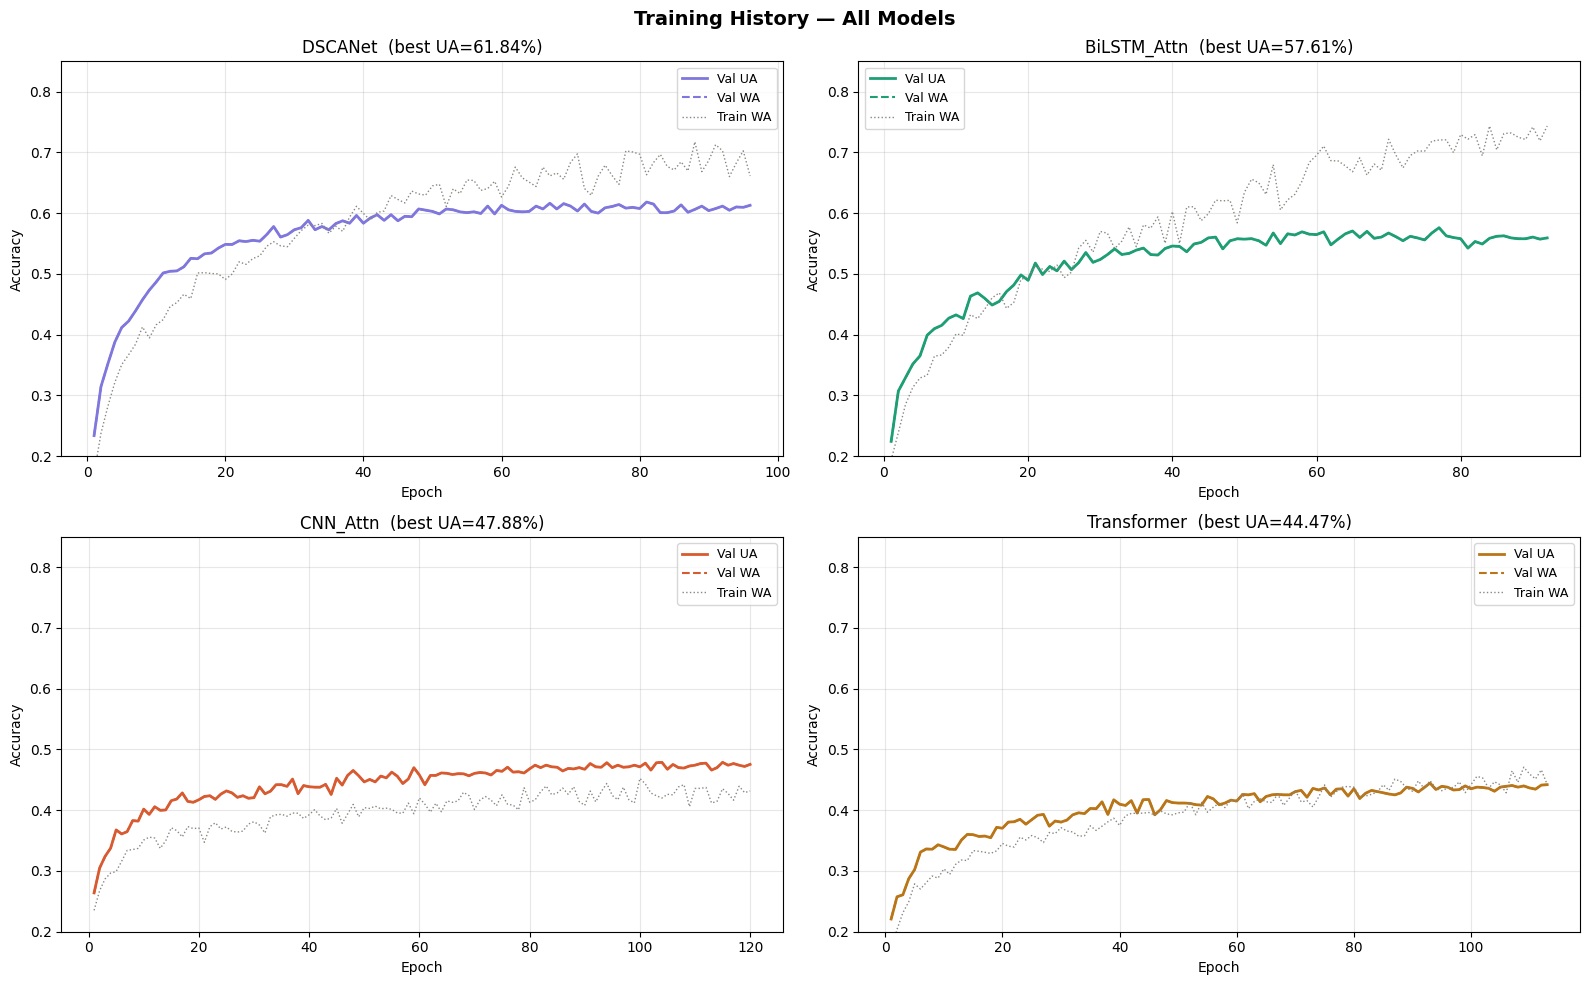

In [50]:
# Training curves for all models 
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Training History — All Models', fontsize=14, fontweight='bold')
colors = {'DSCANet':'#7F77DD','BiLSTM_Attn':'#1D9E75','CNN_Attn':'#D85A30','Transformer':'#BA7517'}

axes = axes.flatten()
for i, (name, h) in enumerate(all_histories.items()):
    ep = range(1, len(h['train_loss'])+1)
    ax = axes[i]
    ax.plot(ep, h['val_ua'],   color=colors[name], linewidth=2, label='Val UA')
    ax.plot(ep, h['val_acc'],  color=colors[name], linewidth=1.5, linestyle='--', label='Val WA')
    ax.plot(ep, h['train_acc'],color='#888780', linewidth=1, linestyle=':', label='Train WA')
    ax.set_title(f'{name}  (best UA={best_val_uas[name]:.2%})')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
    ax.legend(fontsize=9); ax.grid(alpha=0.3)
    ax.set_ylim(0.2, 0.85)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'all_models_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Full test-set evaluation for all models
print('='*95)
print(f'  {"MODEL":<18}  {"Test WA":>8}  {"Test UA":>8}  {"angry":>7}  {"sad":>6}  {"disgust":>8}  {"fear":>6}  {"happy":>6}  {"neutral":>9} ')
print('─'*95)

all_test_results = {}
target_names = [int_to_label[i] for i in range(NUM_CLASSES)]

for name, model in trained_models.items():
    _, wa, ua, preds, labels = evaluate(model, test_loader, criterion, DEVICE)
    # Per-class accuracy
    per = {int_to_label[c]: (preds[labels==c]==c).mean() for c in range(NUM_CLASSES)}
    all_test_results[name] = {'wa':wa,'ua':ua,'preds':preds,'labels':labels,'per':per}
    print(f'  {name:<18}  {wa:>8.2%}  {ua:>8.2%}  {per["angry"]:>7.2%}  {per["sad"]:>6.2%}  {per["disgust"]:>8.2%}  {per["fear"]:>6.2%}  {per["happy"]:>6.2%}  {per["neutral"]:>9.2%}')

print('='*95)

# Identify best model for personal project
best_name = max(all_test_results, key=lambda k: all_test_results[k]['ua'])
print(f'\n→ Best model for personal project: {best_name} (UA={all_test_results[best_name]["ua"]:.2%})')

  MODEL                Test WA   Test UA    angry     sad   disgust    fear   happy    neutral 
───────────────────────────────────────────────────────────────────────────────────────────────
  DSCANet               61.44%    61.42%   76.31%  64.52%    49.19%  52.02%  56.63%     69.88%
  BiLSTM_Attn           57.28%    57.27%   63.45%  66.13%    45.56%  52.42%  51.41%     64.66%
  CNN_Attn              48.69%    48.68%   60.24%  52.42%    33.06%  39.11%  48.19%     59.04%
  Transformer           43.66%    43.65%   56.63%  52.42%    27.82%  37.90%  39.76%     47.39%

→ Best model for personal project: DSCANet (UA=61.42%)


In [54]:
# Detailed report for the best model 
r = all_test_results[best_name]
print(f'Detailed results for {best_name}:')
print(classification_report(r['labels'], r['preds'], target_names=target_names, digits=4))

Detailed results for DSCANet:
              precision    recall  f1-score   support

       angry     0.7252    0.7631    0.7436       249
     disgust     0.6040    0.4919    0.5422       248
        fear     0.5837    0.5202    0.5501       248
       happy     0.6026    0.5663    0.5839       249
     neutral     0.6105    0.6988    0.6517       249
         sad     0.5575    0.6452    0.5981       248

    accuracy                         0.6144      1491
   macro avg     0.6139    0.6142    0.6116      1491
weighted avg     0.6140    0.6144    0.6117      1491



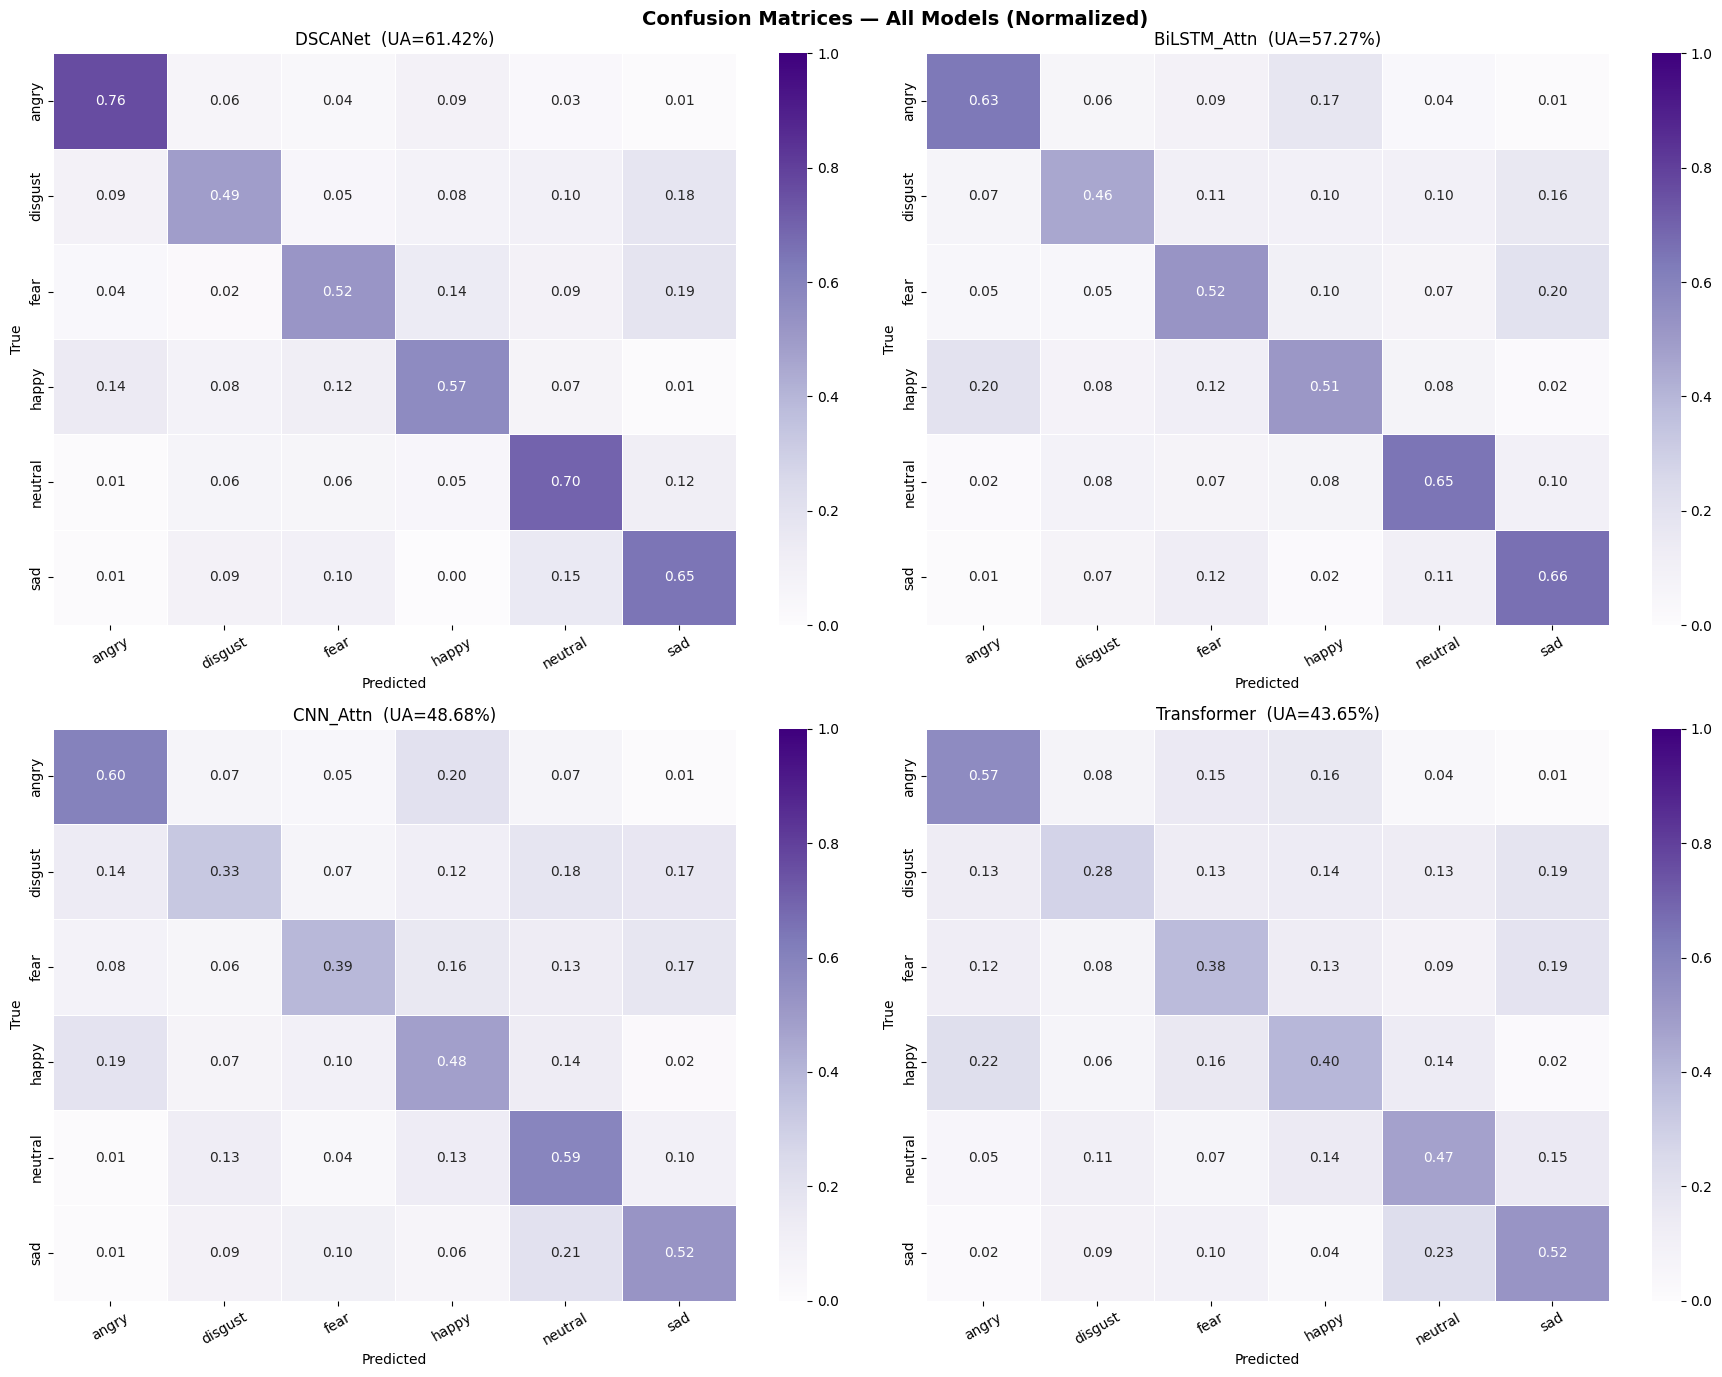

In [55]:
# Confusion matrices for all 4 models
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('Confusion Matrices — All Models (Normalized)', fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, (name, r) in enumerate(all_test_results.items()):
    cm = confusion_matrix(r['labels'], r['preds'])
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Purples',
                xticklabels=target_names, yticklabels=target_names,
                ax=axes[i], linewidths=0.5, linecolor='white', vmin=0, vmax=1)
    axes[i].set_title(f'{name}  (UA={r["ua"]:.2%})')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('True')
    axes[i].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'all_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

In [58]:
# DS-CANet ablation (proves cross-attention contribution)
class DSCANet_NoCrossAttn(nn.Module):
    """Same as DSCANet but cross-attention replaced with naive concatenation."""
    def __init__(self, spectral_dim, temporal_dim, d_model=64,
                 num_heads=4, num_classes=6, dropout=0.5,
                 lstm_hidden=64, lstm_layers=2, temporal_steps=10):
        super().__init__()
        self.spec_proj = nn.Sequential(
            nn.Linear(spectral_dim, d_model), nn.LayerNorm(d_model), nn.GELU())
        self.spec_attn = nn.MultiheadAttention(d_model, num_heads, dropout=dropout, batch_first=True)
        self.spec_norm = nn.LayerNorm(d_model)
        assert temporal_dim % temporal_steps == 0
        step_dim = temporal_dim // temporal_steps
        self.step_proj = nn.Linear(step_dim, lstm_hidden)
        self.bilstm    = nn.LSTM(lstm_hidden, lstm_hidden, lstm_layers,
                                 batch_first=True, bidirectional=True,
                                 dropout=dropout if lstm_layers>1 else 0)
        self.lstm_proj = nn.Sequential(
            nn.Linear(2*lstm_hidden, d_model), nn.LayerNorm(d_model), nn.GELU())
        self.temp_attn = nn.MultiheadAttention(d_model, num_heads, dropout=dropout, batch_first=True)
        self.temp_norm = nn.LayerNorm(d_model)
        self.temporal_steps = temporal_steps
        self.pool_a    = EmotionAwarePooling(d_model)
        self.pool_b    = EmotionAwarePooling(d_model)
        self.drop      = nn.Dropout(dropout)
        # Naive concat fusion instead of cross-attention
        self.fusion    = nn.Sequential(nn.Linear(d_model*2, d_model), nn.LayerNorm(d_model))
        self.head      = nn.Sequential(
            nn.Linear(d_model, d_model//2), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(d_model//2, num_classes))

    def forward(self, x_spec, x_temp):
        a = self.spec_proj(x_spec).unsqueeze(1)
        ao, _ = self.spec_attn(a, a, a)
        a = self.spec_norm(a + self.drop(ao))
        B = x_temp.size(0)
        b = x_temp.view(B, self.temporal_steps, -1)
        b = self.step_proj(b)
        b, _ = self.bilstm(b)
        b = self.lstm_proj(b)
        bo, _ = self.temp_attn(b, b, b)
        b = self.temp_norm(b + self.drop(bo))
        a = self.pool_a(a)
        b = self.pool_b(b)
        fused = self.fusion(torch.cat([a, b], dim=-1))
        return self.head(fused)


abl_model = DSCANet_NoCrossAttn(
    spectral_dim=SPECTRAL_DIM, temporal_dim=TEMPORAL_DIM,
    d_model=D_MODEL, num_heads=NUM_HEADS, num_classes=NUM_CLASSES,
    dropout=DROPOUT, lstm_hidden=LSTM_HIDDEN, lstm_layers=LSTM_LAYERS,
    temporal_steps=10).to(DEVICE)

abl_model, abl_val_ua, _ = train_model(abl_model, 'DSCANet_NoCrossAttn', MODEL_CONFIGS['DSCANet'])
_, abl_wa, abl_ua, _, _  = evaluate(abl_model, test_loader, criterion, DEVICE)

dsca_wa = all_test_results['DSCANet']['wa']
dsca_ua = all_test_results['DSCANet']['ua']

print('\n' + '='*55)
print('         ABLATION: CROSS-ATTENTION CONTRIBUTION')
print('='*55)
print(f'  {"DS-CANet (full)":<28} WA={dsca_wa:.2%}  UA={dsca_ua:.2%}')
print(f'  {"DS-CANet w/o cross-attn":<28} WA={abl_wa:.2%}  UA={abl_ua:.2%}')
print('─'*55)
print(f'  {"Gain from cross-attention":<28} WA={dsca_wa-abl_wa:+.2%}  UA={dsca_ua-abl_ua:+.2%}')
print('='*55)


──────────────────────────────────────────────────────────────────────
Training: DSCANet_NoCrossAttn
  lr=0.0001  dropout=0.45  d_model=128  patience=15
──────────────────────────────────────────────────────────────────────
  Ep |   TrLoss |   TrAcc |   VaLoss |    VaWA |    VaUA |    Gap
────────────────────────────────────────────────────────────
   1 |   1.4474 | 18.29% |   1.2561 | 23.54% | 23.51% | -5.3%
     ↑ New best UA: 23.51%
   2 |   1.4399 | 20.85% |   1.2083 | 28.44% | 28.45% | -7.6%
     ↑ New best UA: 28.45%
   3 |   1.3842 | 23.86% |   1.1681 | 32.06% | 32.07% | -8.2%
     ↑ New best UA: 32.07%
   4 |   1.3460 | 26.16% |   1.1275 | 33.60% | 33.63% | -7.4%
     ↑ New best UA: 33.63%
   5 |   1.3121 | 29.10% |   1.0896 | 36.75% | 36.78% | -7.7%
     ↑ New best UA: 36.78%
   6 |   1.2259 | 30.55% |   1.0611 | 38.70% | 38.71% | -8.1%
     ↑ New best UA: 38.71%
   7 |   1.2609 | 33.31% |   1.0218 | 41.11% | 41.12% | -7.8%
     ↑ New best UA: 41.12%
   8 |   1.2067 | 32.92% 

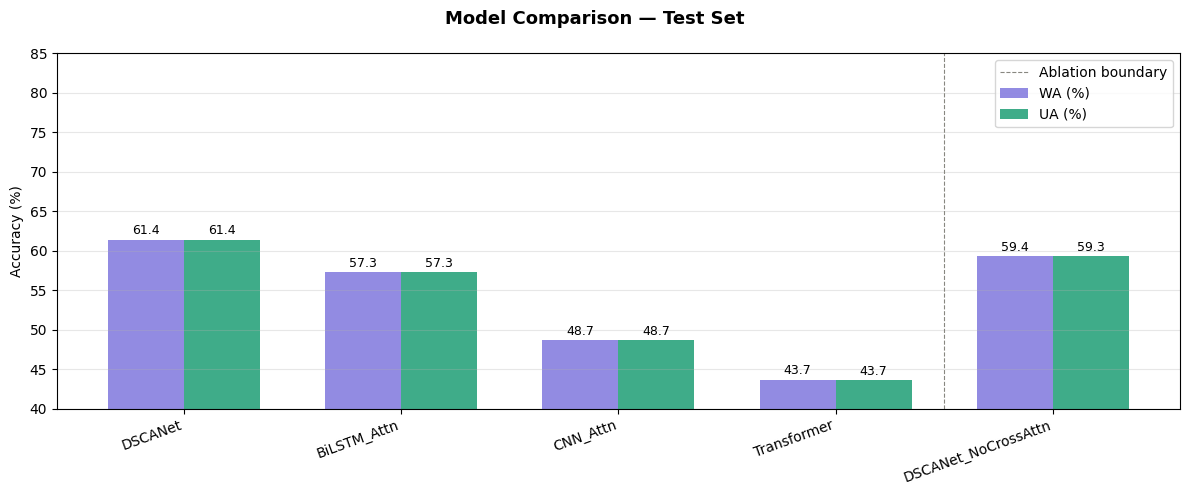

In [61]:
# Final comparison bar chart
model_names = list(all_test_results.keys()) + ['DSCANet_NoCrossAttn']
uas = [all_test_results[n]['ua'] for n in all_test_results] + [abl_ua]
was = [all_test_results[n]['wa'] for n in all_test_results] + [abl_wa]

x   = np.arange(len(model_names))
w   = 0.35
fig, ax = plt.subplots(figsize=(12, 5))
fig.suptitle('Model Comparison — Test Set', fontsize=13, fontweight='bold')

bars_wa = ax.bar(x - w/2, [v*100 for v in was], w, label='WA (%)', color='#7F77DD', alpha=0.85)
bars_ua = ax.bar(x + w/2, [v*100 for v in uas], w, label='UA (%)', color='#1D9E75', alpha=0.85)

for bar in bars_wa:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=9)
for bar in bars_ua:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=9)

ax.axvline(x=3.5, color='#888780', linestyle='--', linewidth=0.8, label='Ablation boundary')
ax.set_xticks(x); ax.set_xticklabels(model_names, rotation=20, ha='right')
ax.set_ylabel('Accuracy (%)'); ax.set_ylim(40, 85)
ax.legend(); ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [62]:
# Save everything 

# Save all model weights
for name, model in trained_models.items():
    torch.save(model.state_dict(), OUTPUT_DIR / f'{name}_final.pt')

# Save full results as JSON
results_summary = {
    name: {
        'test_wa': round(r['wa'], 4),
        'test_ua': round(r['ua'], 4),
        'per_class': {k: round(float(v), 4) for k, v in r['per'].items()}
    }
    for name, r in all_test_results.items()
}
results_summary['DSCANet_NoCrossAttn'] = {
    'test_wa': round(abl_wa, 4),
    'test_ua': round(abl_ua, 4),
}
results_summary['cross_attn_gain_ua'] = round(dsca_ua - abl_ua, 4)
results_summary['best_model']         = best_name
results_summary['label_to_int']       = label_to_int
results_summary['int_to_label']       = {str(k): v for k, v in int_to_label.items()}
results_summary['hyperparams'] = {
    'd_model': D_MODEL, 'num_heads': NUM_HEADS, 'dropout': DROPOUT,
    'lstm_hidden': LSTM_HIDDEN, 'lr': LR, 'spectral_dim': SPECTRAL_DIM,
    'temporal_dim': TEMPORAL_DIM, 'feature_dim': FEATURE_DIM
}

with open(OUTPUT_DIR / 'all_results.json', 'w') as f:
    json.dump(results_summary, f, indent=2)

print('Saved to Drive:')
for f in sorted(OUTPUT_DIR.iterdir()):
    size = f.stat().st_size / 1024
    print(f'  {f.name:<40} ({size:.0f} KB)')

print(f'\nBest model: {best_name} (UA={best_val_uas[best_name]:.2%})')

Saved to Drive:
  BiLSTM_Attn_best.pt                      (4560 KB)
  BiLSTM_Attn_final.pt                     (4560 KB)
  CNN_Attn_best.pt                         (446 KB)
  CNN_Attn_final.pt                        (446 KB)
  DSCANet_NoCrossAttn_best.pt              (907 KB)
  DSCANet_best.pt                          (4523 KB)
  DSCANet_final.pt                         (4523 KB)
  Transformer_best.pt                      (3157 KB)
  Transformer_final.pt                     (3157 KB)
  all_confusion_matrices.png               (269 KB)
  all_models_curves.png                    (245 KB)
  all_results.json                         (1 KB)
  model_comparison.png                     (72 KB)
  scaler.pkl                               (9 KB)

Best model: DSCANet (UA=61.84%)


#### Model Re-Training with hyperparameter tuning

In [40]:
# ═══════════════════════════════════════════════════════════════
# RE-DEFINE ALL TRAINING UTILITIES
# ═══════════════════════════════════════════════════════════════

def mixup_batch(xs, xt, labels, num_classes, alpha=0.3):
    lam  = np.random.beta(alpha, alpha)
    lam  = max(lam, 1 - lam)
    perm = torch.randperm(xs.size(0), device=xs.device)
    xs_m = lam*xs + (1-lam)*xs[perm]
    xt_m = lam*xt + (1-lam)*xt[perm]
    y_oh = F.one_hot(labels, num_classes).float()
    y_m  = lam*y_oh + (1-lam)*y_oh[perm]
    return xs_m, xt_m, y_m


def train_one_epoch(model, loader, optimizer, criterion, device,
                    num_classes, mixup_prob=0.5, mixup_alpha=0.3):
    model.train()
    kl  = nn.KLDivLoss(reduction='batchmean')
    tot_loss, tot_correct, tot_n = 0., 0, 0
    for xs, xt, labels in loader:
        xs, xt, labels = xs.to(device), xt.to(device), labels.to(device)
        optimizer.zero_grad()
        if np.random.random() < mixup_prob:
            xs_m, xt_m, y_soft = mixup_batch(xs, xt, labels, num_classes, mixup_alpha)
            logits = model(xs_m, xt_m)
            loss   = kl(F.log_softmax(logits, dim=-1), y_soft)
        else:
            logits = model(xs, xt)
            loss   = criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        preds = logits.argmax(-1)
        tot_correct += (preds == labels).sum().item()
        tot_loss    += loss.item() * len(labels)
        tot_n       += len(labels)
    return tot_loss/tot_n, tot_correct/tot_n


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    tot_loss, tot_correct, tot_n = 0., 0, 0
    all_preds, all_labels = [], []
    for xs, xt, labels in loader:
        xs, xt, labels = xs.to(device), xt.to(device), labels.to(device)
        logits = model(xs, xt)
        loss   = criterion(logits, labels)
        preds  = logits.argmax(-1)
        tot_correct += (preds == labels).sum().item()
        tot_loss    += loss.item() * len(labels)
        tot_n       += len(labels)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    per_class  = [(all_preds[all_labels==c]==c).mean()
                  for c in range(NUM_CLASSES) if (all_labels==c).sum()>0]
    return tot_loss/tot_n, tot_correct/tot_n, np.mean(per_class), all_preds, all_labels


def make_scheduler(optimizer, warmup_epochs, total_epochs):
    warmup = LambdaLR(optimizer, lambda e: min(1.0, (e+1)/warmup_epochs))
    cosine = CosineAnnealingLR(optimizer, T_max=total_epochs-warmup_epochs, eta_min=1e-6)
    return SequentialLR(optimizer, [warmup, cosine], milestones=[warmup_epochs])


def train_model(model, name, cfg):
    opt   = AdamW(model.parameters(), lr=cfg['lr'], weight_decay=cfg['weight_decay'])
    sched = make_scheduler(opt, cfg['warmup'], EPOCHS)
    best_ua, best_wts = 0.0, copy.deepcopy(model.state_dict())
    patience  = 0
    history   = {'train_loss':[],'train_acc':[],'val_loss':[],'val_acc':[],'val_ua':[]}
    swa_ckpts = []
    t0        = time.time()

    print(f'\n{"─"*70}')
    print(f'Training: {name}')
    print(f'  lr={cfg["lr"]}  dropout={cfg["dropout"]}  d_model={cfg["d_model"]}  patience={cfg["patience"]}')
    print(f'{"─"*70}')
    print(f'{"Ep":>4} | {"TrLoss":>8} | {"TrAcc":>7} | {"VaLoss":>8} | {"VaWA":>7} | {"VaUA":>7} | {"Gap":>6}')
    print('─'*60)

    for epoch in range(1, EPOCHS+1):
        tl, ta = train_one_epoch(model, train_loader, opt, criterion, DEVICE, NUM_CLASSES)
        vl, va, vu, _, _ = evaluate(model, val_loader, criterion, DEVICE)
        sched.step()
        history['train_loss'].append(tl); history['train_acc'].append(ta)
        history['val_loss'].append(vl);   history['val_acc'].append(va)
        history['val_ua'].append(vu)
        if epoch >= EPOCHS - 10:
            swa_ckpts.append(copy.deepcopy(model.state_dict()))
        print(f'{epoch:>4} | {tl:>8.4f} | {ta:>6.2%} | {vl:>8.4f} | {va:>6.2%} | {vu:>6.2%} | {ta-va:>+5.1%}')
        if vu > best_ua:
            best_ua  = vu
            best_wts = copy.deepcopy(model.state_dict())
            torch.save(best_wts, OUTPUT_DIR / f'{name}_best.pt')
            print(f'     ↑ New best UA: {best_ua:.2%}')
            patience = 0
        else:
            patience += 1
        if patience >= cfg['patience']:
            print(f'Early stop at epoch {epoch}')
            break

    # SWA
    if len(swa_ckpts) >= 2:
        swa_state = copy.deepcopy(swa_ckpts[0])
        for key in swa_state:
            for ck in swa_ckpts[1:]:
                swa_state[key] = swa_state[key] + ck[key]
            swa_state[key] = swa_state[key] / len(swa_ckpts)
        model.load_state_dict(swa_state)
        _, _, swa_ua, _, _ = evaluate(model, val_loader, criterion, DEVICE)
        if swa_ua > best_ua:
            best_ua  = swa_ua
            best_wts = swa_state
            print(f'SWA improved val UA to {swa_ua:.2%}')

    model.load_state_dict(best_wts)
    print(f'Done in {(time.time()-t0)/60:.1f} min  |  Best Val UA: {best_ua:.2%}')
    return model, best_ua, history

print('All training utilities defined: mixup_batch, train_one_epoch, evaluate, train_model')

All training utilities defined: mixup_batch, train_one_epoch, evaluate, train_model


In [41]:
# ═══════════════════════════════════════════════════════════════
# MODEL CONFIGS v2 — TUNED BASED ON v1 TRAINING ANALYSIS
#
# What changed and why:
#
# DSCANet:    unchanged — 61.84% val UA is already healthy
#
# BiLSTM_Attn: dropout 0.40→0.50, weight_decay 3e-4→5e-4, patience 15→12
#   REASON: val loss diverged after epoch 45 (0.87→1.15), clear overfitting
#   in late training. More dropout + stop earlier before divergence.
#
# CNN_Attn:  dropout 0.25→0.15, d_model 128→256, lr 3e-4→4e-4
#   REASON: train WA (~43%) was LOWER than val WA (~48%) = underfitting.
#   Model never had enough capacity. Drop regularization, add capacity.
#
# Transformer: dropout 0.20→0.15, lr 5e-5→2e-4, num_layers 4→6, warmup 10→15
#   REASON: train≈val throughout = underfitting, never converged.
#   LR was too conservative. More layers since regularization is low.
# ═══════════════════════════════════════════════════════════════

MODEL_CONFIGS_V2 = {
    'DSCANet': {
        # Unchanged — working well
        'd_model'        : 128,
        'num_heads'      : 8,
        'lstm_hidden'    : 128,
        'lstm_layers'    : 2,
        'dropout'        : 0.45,
        'lr'             : 1e-4,
        'weight_decay'   : 3e-4,
        'temporal_steps' : 10,
        'warmup'         : 5,
        'patience'       : 15,
        'num_layers'     : None,
        'chunk_size'     : None,
    },
    'BiLSTM_Attn': {
        # MORE dropout + LOWER patience — was overfitting after ep 45
        'd_model'        : 128,
        'num_heads'      : 4,
        'lstm_hidden'    : 128,
        'lstm_layers'    : 3,
        'dropout'        : 0.50,   # ← was 0.40
        'lr'             : 2e-4,
        'weight_decay'   : 5e-4,   # ← was 3e-4
        'temporal_steps' : 27,
        'warmup'         : 5,
        'patience'       : 12,     # ← was 15, stop before val loss diverges
        'num_layers'     : None,
        'chunk_size'     : None,
    },
    'CNN_Attn': {
        # LESS dropout + MORE capacity — was underfitting (train < val)
        'd_model'        : 256,    # ← was 128, needs more capacity
        'num_heads'      : 4,
        'lstm_hidden'    : None,
        'lstm_layers'    : None,
        'dropout'        : 0.15,   # ← was 0.25, too much regularization
        'lr'             : 4e-4,   # ← was 3e-4
        'weight_decay'   : 2e-4,
        'temporal_steps' : None,
        'warmup'         : 3,
        'patience'       : 20,
        'num_layers'     : None,
        'chunk_size'     : None,
    },
    'Transformer': {
        # MUCH HIGHER lr + MORE layers — was severely underfitting
        'd_model'        : 128,
        'num_heads'      : 8,
        'lstm_hidden'    : None,
        'lstm_layers'    : None,
        'dropout'        : 0.15,   # ← was 0.20
        'lr'             : 2e-4,   # ← was 5e-5, too slow to converge
        'weight_decay'   : 1e-4,
        'temporal_steps' : None,
        'warmup'         : 15,     # ← was 10, more warmup since LR is higher
        'patience'       : 20,
        'num_layers'     : 6,      # ← was 4, more depth since dropout is low
        'chunk_size'     : 7,      # 378/7=54 tokens
    },
}

EPOCHS = 120

print('MODEL_CONFIGS_V2 ready')
print(f'{"Model":<16} {"dropout":>8} {"lr":>8} {"d_model":>8} {"patience":>9}')
print('─'*55)
for name, cfg in MODEL_CONFIGS_V2.items():
    print(f'{name:<16} {cfg["dropout"]:>8} {cfg["lr"]:>8} {cfg["d_model"]:>8} {cfg["patience"]:>9}')

MODEL_CONFIGS_V2 ready
Model             dropout       lr  d_model  patience
───────────────────────────────────────────────────────
DSCANet              0.45   0.0001      128        15
BiLSTM_Attn           0.5   0.0002      128        12
CNN_Attn             0.15   0.0004      256        20
Transformer          0.15   0.0002      128        20


In [42]:
# ═══════════════════════════════════════════════════════════════
# BUILD MODELS V2
# ═══════════════════════════════════════════════════════════════

def build_models_v2():
    cfg = MODEL_CONFIGS_V2
    return {
        'DSCANet': DSCANet(
            spectral_dim=SPECTRAL_DIM, temporal_dim=TEMPORAL_DIM,
            d_model=cfg['DSCANet']['d_model'],
            num_heads=cfg['DSCANet']['num_heads'],
            num_classes=NUM_CLASSES,
            dropout=cfg['DSCANet']['dropout'],
            lstm_hidden=cfg['DSCANet']['lstm_hidden'],
            lstm_layers=cfg['DSCANet']['lstm_layers'],
            temporal_steps=cfg['DSCANet']['temporal_steps']),

        'BiLSTM_Attn': BiLSTMAttention(
            input_dim=FEATURE_DIM,
            d_model=cfg['BiLSTM_Attn']['d_model'],
            num_heads=cfg['BiLSTM_Attn']['num_heads'],
            num_classes=NUM_CLASSES,
            dropout=cfg['BiLSTM_Attn']['dropout'],
            lstm_hidden=cfg['BiLSTM_Attn']['lstm_hidden'],
            lstm_layers=cfg['BiLSTM_Attn']['lstm_layers'],
            temporal_steps=cfg['BiLSTM_Attn']['temporal_steps']),

        'CNN_Attn': CNNAttention(
            input_dim=FEATURE_DIM,
            d_model=cfg['CNN_Attn']['d_model'],    # now 256
            num_heads=cfg['CNN_Attn']['num_heads'],
            num_classes=NUM_CLASSES,
            dropout=cfg['CNN_Attn']['dropout']),

        'Transformer': TransformerSER(
            input_dim=FEATURE_DIM,
            d_model=cfg['Transformer']['d_model'],
            num_heads=cfg['Transformer']['num_heads'],
            num_classes=NUM_CLASSES,
            dropout=cfg['Transformer']['dropout'],
            num_layers=cfg['Transformer']['num_layers'],  # now 6
            chunk_size=cfg['Transformer']['chunk_size']),
    }

models_v2 = {name: m.to(DEVICE) for name, m in build_models_v2().items()}

# Dry run
dummy_spec = torch.randn(4, SPECTRAL_DIM).to(DEVICE)
dummy_temp = torch.randn(4, TEMPORAL_DIM).to(DEVICE)

print(f'{"Model":<16} {"Params":>12}  Output')
print('─'*40)
for name, m in models_v2.items():
    params = sum(p.numel() for p in m.parameters() if p.requires_grad)
    out    = m(dummy_spec, dummy_temp)
    print(f'{name:<16} {params:>12,}  {tuple(out.shape)}')

print('\nAll v2 models ready.')

Model                  Params  Output
────────────────────────────────────────
DSCANet             1,152,328  (4, 6)
BiLSTM_Attn         1,164,871  (4, 6)
CNN_Attn              358,279  (4, 6)
Transformer         1,199,431  (4, 6)

All v2 models ready.


/tmp/ipykernel_662/2764767033.py:21: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder  = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)


In [43]:
# ═══════════════════════════════════════════════════════════════
# TRAIN ALL MODELS v2 — TUNED HYPERPARAMETERS
# Previous results preserved in trained_models (v1)
# New results stored in trained_models_v2
# ═══════════════════════════════════════════════════════════════

trained_models_v2 = {}
best_val_uas_v2   = {}
all_histories_v2  = {}

for name, model in models_v2.items():
    def reset_weights(m):
        if hasattr(m, 'reset_parameters'):
            m.reset_parameters()
    model.apply(reset_weights)

    trained_model, best_ua, history = train_model(model, name, MODEL_CONFIGS_V2[name])
    trained_models_v2[name] = trained_model
    best_val_uas_v2[name]   = best_ua
    all_histories_v2[name]  = history

print('\n' + '='*50)
print('   VALIDATION UA SUMMARY — v2 TUNED')
print('='*50)
for name, ua in sorted(best_val_uas_v2.items(), key=lambda x: -x[1]):
    bar = '█' * int(ua * 38)
    print(f'  {name:<16} {ua:.2%}  {bar}')
print('='*50)


──────────────────────────────────────────────────────────────────────
Training: DSCANet
  lr=0.0001  dropout=0.45  d_model=128  patience=15
──────────────────────────────────────────────────────────────────────
  Ep |   TrLoss |   TrAcc |   VaLoss |    VaWA |    VaUA |    Gap
────────────────────────────────────────────────────────────
   1 |   1.4334 | 18.67% |   1.2321 | 25.15% | 25.15% | -6.5%
     ↑ New best UA: 25.15%
   2 |   1.3466 | 23.56% |   1.1728 | 29.91% | 29.93% | -6.4%
     ↑ New best UA: 29.93%
   3 |   1.3348 | 28.44% |   1.1149 | 34.07% | 34.10% | -5.6%
     ↑ New best UA: 34.10%
   4 |   1.3022 | 33.04% |   1.0558 | 39.10% | 39.11% | -6.1%
     ↑ New best UA: 39.11%
   5 |   1.2320 | 35.32% |   1.0072 | 41.52% | 41.52% | -6.2%
     ↑ New best UA: 41.52%
   6 |   1.1710 | 39.40% |   0.9722 | 43.13% | 43.12% | -3.7%
     ↑ New best UA: 43.12%
   7 |   1.1730 | 39.39% |   0.9535 | 45.81% | 45.81% | -6.4%
     ↑ New best UA: 45.81%
   8 |   1.1310 | 42.24% |   0.9483 |

In [44]:
# ═══════════════════════════════════════════════════════════════
# TEST SET EVALUATION — v2 MODELS
# ═══════════════════════════════════════════════════════════════

all_test_results_v2 = {}
target_names = [int_to_label[i] for i in range(NUM_CLASSES)]

for name, model in trained_models_v2.items():
    _, wa, ua, preds, labels = evaluate(model, test_loader, criterion, DEVICE)
    per = {int_to_label[c]: (preds[labels==c]==c).mean() for c in range(NUM_CLASSES)}
    all_test_results_v2[name] = {'wa':wa, 'ua':ua, 'preds':preds, 'labels':labels, 'per':per}

# Side-by-side comparison v1 vs v2
print('='*90)
print(f'  {"MODEL":<16}  {"v1 UA":>7}  {"v2 UA":>7}  {"GAIN":>6}  |  '
      f'{"angry":>7}  {"sad":>6}  {"disgust":>8}  {"fear":>6}  {"happy":>7}  {"neutral":>8}')
print('─'*90)

# Use v1 results from all_test_results if it exists, else show v2 only
try:
    v1 = all_test_results
except NameError:
    v1 = {}

for name in trained_models_v2:
    r2  = all_test_results_v2[name]
    ua2 = r2['ua']
    ua1 = v1[name]['ua'] if name in v1 else float('nan')
    gain = ua2 - ua1 if name in v1 else float('nan')
    gain_str = f'{gain:+.2%}' if not (gain != gain) else '  n/a'
    print(f'  {name:<16}  {ua1:>7.2%}  {ua2:>7.2%}  {gain_str:>6}  |  '
          f'{r2["per"]["angry"]:>7.2%}  {r2["per"]["sad"]:>6.2%}  '
          f'{r2["per"]["disgust"]:>8.2%}  {r2["per"]["fear"]:>6.2%}  '
          f'{r2["per"]["happy"]:>7.2%}  {r2["per"]["neutral"]:>8.2%}')

print('='*90)

# Best model
best_v2 = max(all_test_results_v2, key=lambda k: all_test_results_v2[k]['ua'])
print(f'\nBest v2 model: {best_v2} (UA={all_test_results_v2[best_v2]["ua"]:.2%})')
print(f'\nDetailed results for {best_v2}:')
r = all_test_results_v2[best_v2]
print(classification_report(r['labels'], r['preds'], target_names=target_names, digits=4))

  MODEL               v1 UA    v2 UA    GAIN  |    angry     sad   disgust    fear    happy   neutral
──────────────────────────────────────────────────────────────────────────────────────────
  DSCANet              nan%   62.50%     n/a  |   77.51%  67.34%    52.82%  52.02%   60.24%    65.06%
  BiLSTM_Attn          nan%   57.13%     n/a  |   71.49%  68.15%    40.32%  50.40%   51.41%    61.04%
  CNN_Attn             nan%   53.31%     n/a  |   67.47%  60.48%    40.32%  41.53%   51.41%    58.63%
  Transformer          nan%   51.50%     n/a  |   63.45%  68.55%    33.87%  36.29%   48.19%    58.63%

Best v2 model: DSCANet (UA=62.50%)

Detailed results for DSCANet:
              precision    recall  f1-score   support

       angry     0.7338    0.7751    0.7539       249
     disgust     0.6037    0.5282    0.5634       248
        fear     0.5785    0.5202    0.5478       248
       happy     0.5837    0.6024    0.5929       249
     neutral     0.6667    0.6506    0.6585       249
       

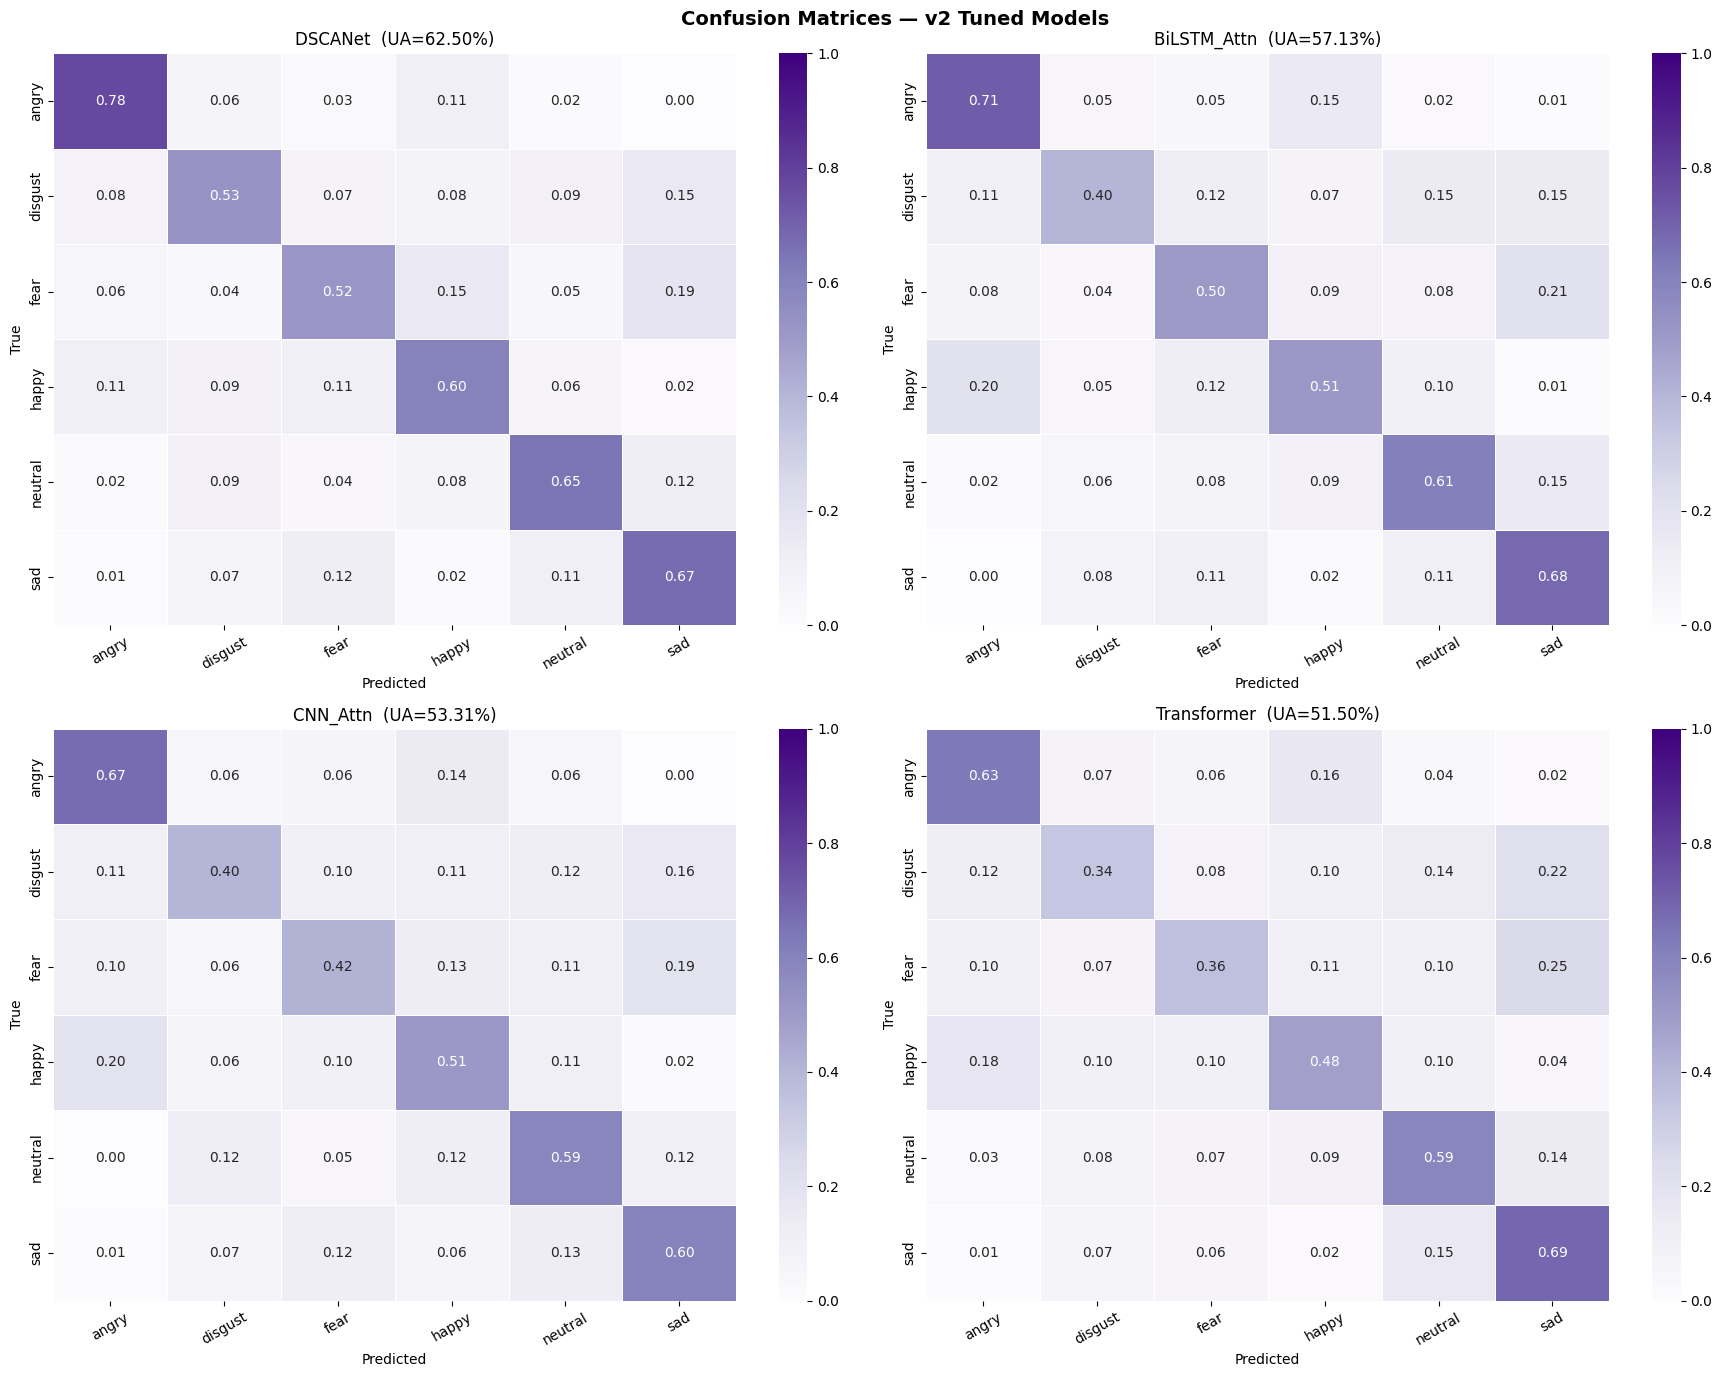

In [45]:
# ═══════════════════════════════════════════════════════════════
# CONFUSION MATRICES — v2 MODELS
# ═══════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('Confusion Matrices — v2 Tuned Models', fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, (name, r) in enumerate(all_test_results_v2.items()):
    cm      = confusion_matrix(r['labels'], r['preds'])
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Purples',
                xticklabels=target_names, yticklabels=target_names,
                ax=axes[i], linewidths=0.5, linecolor='white', vmin=0, vmax=1)
    axes[i].set_title(f'{name}  (UA={r["ua"]:.2%})')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('True')
    axes[i].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'confusion_matrices_v2.png', dpi=150, bbox_inches='tight')
plt.show()

In [46]:
# ═══════════════════════════════════════════════════════════════
# DSCANET ENSEMBLE — 3 seeds, average predictions
# Seed 42 is already trained (trained_models_v2['DSCANet'])
# Train seeds 123 and 777
# ═══════════════════════════════════════════════════════════════

def train_dscanet_seed(seed):
    torch.manual_seed(seed)
    np.random.seed(seed)
    cfg = MODEL_CONFIGS_V2['DSCANet']
    m = DSCANet(
        spectral_dim=SPECTRAL_DIM, temporal_dim=TEMPORAL_DIM,
        d_model=cfg['d_model'], num_heads=cfg['num_heads'],
        num_classes=NUM_CLASSES, dropout=cfg['dropout'],
        lstm_hidden=cfg['lstm_hidden'], lstm_layers=cfg['lstm_layers'],
        temporal_steps=cfg['temporal_steps']
    ).to(DEVICE)
    m, ua, _ = train_model(m, f'DSCANet_seed{seed}', cfg)
    return m, ua

m2, ua2 = train_dscanet_seed(123)
m3, ua3 = train_dscanet_seed(777)

print(f'\nIndividual UAs:')
print(f'  seed=42  : {best_val_uas_v2["DSCANet"]:.2%}')
print(f'  seed=123 : {ua2:.2%}')
print(f'  seed=777 : {ua3:.2%}')

# Ensemble predict
@torch.no_grad()
def ensemble_predict(models, loader, device):
    for m in models: m.eval()
    all_preds, all_labels = [], []
    for xs, xt, labels in loader:
        xs, xt = xs.to(device), xt.to(device)
        probs = torch.zeros(xs.size(0), NUM_CLASSES).to(device)
        for m in models:
            probs += F.softmax(m(xs, xt), dim=-1)
        probs /= len(models)
        all_preds.extend(probs.argmax(-1).cpu().numpy())
        all_labels.extend(labels.numpy())
    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    wa  = accuracy_score(all_labels, all_preds)
    per = [(all_preds[all_labels==c]==c).mean() for c in range(NUM_CLASSES)]
    return wa, np.mean(per), all_preds, all_labels

ensemble = [trained_models_v2['DSCANet'], m2, m3]
ens_wa, ens_ua, ens_preds, ens_labels = ensemble_predict(ensemble, test_loader, DEVICE)

single_ua = all_test_results_v2['DSCANet']['ua']
print(f'\n{"="*55}')
print(f'  Single DSCANet (v2) : UA={single_ua:.2%}')
print(f'  Ensemble  (3×seed)  : UA={ens_ua:.2%}')
print(f'  Gain                : {ens_ua - single_ua:+.2%}')
print(f'{"="*55}')
print(classification_report(ens_labels, ens_preds,
      target_names=target_names, digits=4))

# Save
for seed, m in [(123, m2), (777, m3)]:
    torch.save(m.state_dict(), OUTPUT_DIR / f'DSCANet_v2_seed{seed}.pt')
print('Ensemble models saved.')


──────────────────────────────────────────────────────────────────────
Training: DSCANet_seed123
  lr=0.0001  dropout=0.45  d_model=128  patience=15
──────────────────────────────────────────────────────────────────────
  Ep |   TrLoss |   TrAcc |   VaLoss |    VaWA |    VaUA |    Gap
────────────────────────────────────────────────────────────
   1 |   1.3960 | 20.93% |   1.2314 | 27.23% | 27.23% | -6.3%
     ↑ New best UA: 27.23%
   2 |   1.3964 | 25.27% |   1.1689 | 32.60% | 32.61% | -7.3%
     ↑ New best UA: 32.61%
   3 |   1.3150 | 30.10% |   1.1071 | 35.28% | 35.28% | -5.2%
     ↑ New best UA: 35.28%
   4 |   1.2586 | 32.10% |   1.0569 | 40.11% | 40.11% | -8.0%
     ↑ New best UA: 40.11%
   5 |   1.2490 | 36.90% |   1.0220 | 41.65% | 41.64% | -4.7%
     ↑ New best UA: 41.64%
   6 |   1.1945 | 39.35% |   0.9716 | 43.39% | 43.40% | -4.0%
     ↑ New best UA: 43.40%
   7 |   1.1528 | 41.01% |   0.9481 | 44.94% | 44.93% | -3.9%
     ↑ New best UA: 44.93%
   8 |   1.1167 | 42.74% |   

In [48]:
# ═══════════════════════════════════════════════════════════════
# SAVE ALL v2 MODELS + FINAL SUMMARY
# ═══════════════════════════════════════════════════════════════

for name, model in trained_models_v2.items():
    torch.save(model.state_dict(), OUTPUT_DIR / f'{name}_v2_final.pt')

# Final results JSON
summary = {
    'v1': {name: {'test_ua': round(r['ua'],4), 'test_wa': round(r['wa'],4)}
           for name, r in v1.items()} if v1 else {},
    'v2': {name: {'test_ua': round(r['ua'],4), 'test_wa': round(r['wa'],4)}
           for name, r in all_test_results_v2.items()},
    'ensemble_ua': round(ens_ua, 4),
    'ensemble_wa': round(ens_wa, 4),
    'best_model': best_v2,
}
with open(OUTPUT_DIR / 'final_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print('All v2 models saved. Files in Drive:')
for f in sorted(OUTPUT_DIR.iterdir()):
    mb = f.stat().st_size / (1024*1024)
    print(f'  {f.name:<45} ({mb:.1f} MB)')

All v2 models saved. Files in Drive:
  BiLSTM_Attn_best.pt                           (4.5 MB)
  BiLSTM_Attn_final.pt                          (4.5 MB)
  BiLSTM_Attn_v2_final.pt                       (4.5 MB)
  CNN_Attn_best.pt                              (1.4 MB)
  CNN_Attn_final.pt                             (0.4 MB)
  CNN_Attn_v2_final.pt                          (1.4 MB)
  DSCANet_NoCrossAttn_best.pt                   (0.9 MB)
  DSCANet_best.pt                               (4.4 MB)
  DSCANet_final.pt                              (4.4 MB)
  DSCANet_seed123_best.pt                       (4.4 MB)
  DSCANet_seed777_best.pt                       (4.4 MB)
  DSCANet_v2_final.pt                           (4.4 MB)
  DSCANet_v2_seed123.pt                         (4.4 MB)
  DSCANet_v2_seed777.pt                         (4.4 MB)
  Transformer_best.pt                           (4.6 MB)
  Transformer_final.pt                          (3.1 MB)
  Transformer_v2_final.pt                       (4.